In [1]:
import pandas as pd
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [2]:
data_dir = '../data/processed/'
x_train_path = os.path.join(data_dir, 'x_train.csv')
x_test_path = os.path.join(data_dir, 'x_test.csv')
y_train_path = os.path.join(data_dir, 'y_train.csv')
y_test_path = os.path.join(data_dir, 'y_test.csv')

In [3]:
x_train = pd.read_csv(x_train_path)
x_test = pd.read_csv(x_test_path)
y_train = pd.read_csv(y_train_path).squeeze()
y_test = pd.read_csv(y_test_path).squeeze()

In [4]:
baseline_model = LogisticRegression(max_iter=1000,random_state=42,)
baseline_model.fit(x_train,y_train)

y_predictions = baseline_model.predict(x_test)

print("--- Logistic Regression Baseline Results ----\n")
print(f"Overall Accuracy:{accuracy_score(y_test,y_predictions):.2%}\n")
print(classification_report(y_test,y_predictions))

--- Logistic Regression Baseline Results ----

Overall Accuracy:82.19%

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



c:\Users\jayku\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TypeError: loop of ufunc does not support argument 0 of type float which has no callable rint method

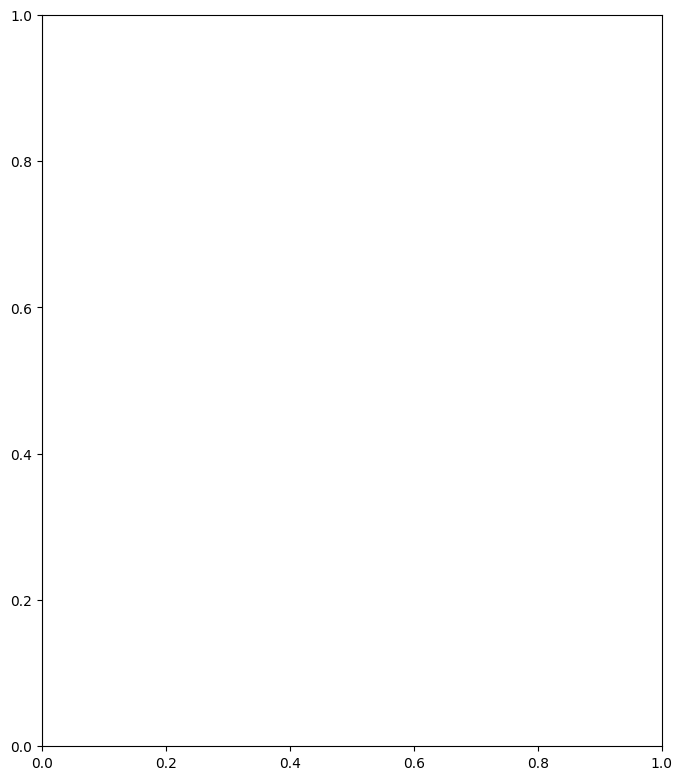

In [5]:
import shap
explainer = shap.Explainer(baseline_model,x_train)
shap_value = explainer(x_test)

shap.summary_plot(shap_value,x_test)


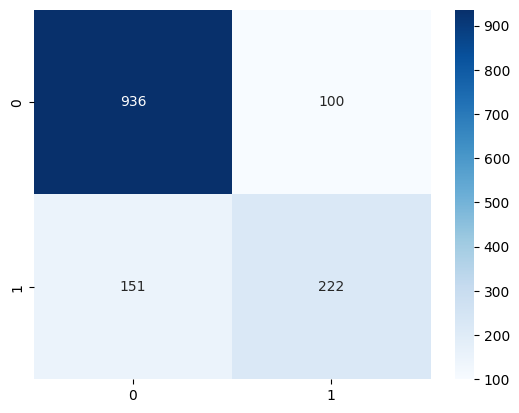

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_predictions)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.show()

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

count_class_0 = y_train.value_counts()[0]
count_class_1 = y_train.value_counts()[1]
imbalance_weight = count_class_0/count_class_1

print(f'mathematical weight applied to churners : {imbalance_weight:.2f}')
xg_model = XGBClassifier(
    scale_pos_weight = imbalance_weight ,
    random_state =42 ,
    eval_metric = 'logloss'
)
xg_model.fit(x_train,y_train)
xg_prediction = xg_model.predict(x_test)
classification_report(
    y_test,xg_prediction
)

mathematical weight applied to churners : 2.77
